### Notebook 5: Monitoring & Learning Agent

**Purpose:** Evaluate each pricing decision against real operational outcomes and simulate a feedback loop that continuously improves pricing efficiency over time.

**Metrics Tracked:**
| Metric | Description |
|---|---|
| Avg Waiting Time Reduction | Queue length proxy reduction across peak periods |
| Customer Response Rate | Demand shift in response to tariff changes (elasticity proxy) |
| Pricing Efficiency Score | Revenue per unit utilization tracked over time |

**Feedback Loop Logic:**
- Track daily revenue gain vs rolling 7-day mean
- Flag underperforming days as recalibration signals
- Simulate model re-calibration trigger

**Assumption:** Queue length is proxied as excess occupancy above the 80th percentile. Actual wait time data is unavailable in both datasets — this is clearly noted as a limitation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 130

BASE  = os.path.normpath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
PROC  = os.path.join(BASE, "data", "processed") + os.sep
PLOTS = os.path.join(BASE, "plots")             + os.sep
OUT   = os.path.join(BASE, "outputs")           + os.sep

tariff_df = pd.read_csv(OUT + "tariff_decisions.csv", parse_dates=['datetime'])
tariff_df['hour'] = tariff_df['datetime'].dt.hour

print(f"Tariff decisions loaded: {tariff_df.shape}")
tariff_df.head(3)

Tariff decisions loaded: (86280, 11)


,datetime,station_id,utilization,pred_utilization,pred_congestion_prob,dynamic_tariff,tariff_regime,revenue_fixed,revenue_dynamic_adj,adjusted_utilization,hour
0,2022-06-19 01:00:00,343,0.071429,0.066863,0.001998,10.5,Discount,1.071429,0.8175,0.077857,1
1,2022-06-19 01:05:00,343,0.071429,0.066863,0.001998,10.5,Discount,1.071429,0.8175,0.077857,1
2,2022-06-19 01:10:00,343,0.071429,0.066863,0.001998,10.5,Discount,1.071429,0.8175,0.077857,1


### 5.1 Queue Length Proxy & Wait Time Reduction
Excess occupancy above the 80% congestion threshold is used as a proxy for queue length and waiting time.

In [3]:
CONGESTION_THRESHOLD = 0.8

tariff_df['queue_before'] = (tariff_df['utilization']          - CONGESTION_THRESHOLD).clip(lower=0)
tariff_df['queue_after']  = (tariff_df['adjusted_utilization'] - CONGESTION_THRESHOLD).clip(lower=0)

# Focus on peak hours
peak_mask = tariff_df['hour'].isin(list(range(7, 10)) + list(range(17, 21)))

queue_peak_before = tariff_df.loc[peak_mask, 'queue_before'].mean()
queue_peak_after  = tariff_df.loc[peak_mask, 'queue_after'].mean()
queue_reduction   = ((queue_peak_before - queue_peak_after) / (queue_peak_before + 1e-9)) * 100

print(f"Peak Queue Proxy Before : {queue_peak_before:.5f}")
print(f"Peak Queue Proxy After  : {queue_peak_after:.5f}")
print(f"Queue Reduction %       : {queue_reduction:.2f}%")

Peak Queue Proxy Before : 0.00000
Peak Queue Proxy After  : 0.00000
Queue Reduction %       : 79.98%


### 5.2 Customer Response Rate — Demand Elasticity Proxy
Measures how much demand shifts in response to tariff changes across different pricing regimes.

In [4]:
tariff_df['tariff_fixed']   = 15.0
tariff_df['price_change']   = (tariff_df['dynamic_tariff'] - tariff_df['tariff_fixed']) / tariff_df['tariff_fixed']
tariff_df['demand_change']  = (tariff_df['adjusted_utilization'] - tariff_df['utilization']) / (tariff_df['utilization'] + 1e-9)

response = tariff_df.groupby('tariff_regime').agg(
    count              = ('utilization', 'count'),
    avg_price_change   = ('price_change', 'mean'),
    avg_demand_change  = ('demand_change', 'mean')
).reset_index()

response['implied_elasticity'] = response['avg_demand_change'] / (response['avg_price_change'] + 1e-9)
response.to_csv(OUT + "customer_response_rate.csv", index=False)
print(response.to_string(index=False))

tariff_regime  count  avg_price_change  avg_demand_change  implied_elasticity
     Baseline  39096               0.0           0.000000            0.000000
     Discount  47154              -0.3           0.086895           -0.289649
        Surge     30               0.5          -0.150000           -0.300000


### 5.3 Pricing Efficiency Score Over Time
Revenue per unit of utilization delivered — tracks whether the feedback loop improves decisions over time.

In [5]:
tariff_df = tariff_df.sort_values('datetime')
tariff_df['rev_per_util_fixed']   = tariff_df['revenue_fixed']       / (tariff_df['utilization']          + 1e-9)
tariff_df['rev_per_util_dynamic'] = tariff_df['revenue_dynamic_adj'] / (tariff_df['adjusted_utilization'] + 1e-9)

tariff_df['date'] = tariff_df['datetime'].dt.date
daily_eff = tariff_df.groupby('date').agg(
    eff_fixed       = ('rev_per_util_fixed',   'mean'),
    eff_dynamic     = ('rev_per_util_dynamic', 'mean'),
    revenue_fixed   = ('revenue_fixed',         'sum'),
    revenue_dynamic = ('revenue_dynamic_adj',   'sum')
).reset_index()
daily_eff['date']             = pd.to_datetime(daily_eff['date'])
daily_eff['revenue_gain_pct'] = ((daily_eff['revenue_dynamic'] - daily_eff['revenue_fixed'])
                                  / daily_eff['revenue_fixed'] * 100)

daily_eff.to_csv(OUT + "daily_efficiency.csv", index=False)
print(f"Days tracked : {len(daily_eff)}")
daily_eff.head()

Days tracked : 30


,date,eff_fixed,eff_dynamic,revenue_fixed,revenue_dynamic,revenue_gain_pct
0,2022-06-19,14.559783,11.925000,11445.889563,10315.555346,-9.875460
1,2022-06-20,15.000000,12.603646,12651.894670,11837.975203,-6.433182
2,2022-06-21,14.890625,12.300000,12482.374660,11458.761551,-8.200468
3,2022-06-22,14.937500,12.089062,11947.986019,10731.444234,-10.181982
4,2022-06-23,14.989583,12.442708,12486.822851,11455.135865,-8.262206


### 5.4 Feedback Loop — Recalibration Signal Detection
Days where revenue gain falls below the rolling 7-day mean trigger a recalibration signal, simulating the agent's self-improvement loop.

In [6]:
daily_eff['rolling_gain_mean'] = daily_eff['revenue_gain_pct'].rolling(7, min_periods=1).mean()
daily_eff['rolling_gain_std']  = daily_eff['revenue_gain_pct'].rolling(7, min_periods=1).std().fillna(0)
daily_eff['recalibration_signal'] = (
    daily_eff['revenue_gain_pct'] < (
        daily_eff['rolling_gain_mean'] - 0.5 * daily_eff['rolling_gain_std']
    )
).astype(int)

n_recalibrations = daily_eff['recalibration_signal'].sum()
recal_rate       = n_recalibrations / len(daily_eff) * 100

print(f"Total monitoring days       : {len(daily_eff)}")
print(f"Recalibration signals fired : {n_recalibrations}")
print(f"Recalibration rate          : {recal_rate:.1f}% of days")

Total monitoring days       : 30
Recalibration signals fired : 6
Recalibration rate          : 20.0% of days


### 5.5 Monitoring Dashboard Visualizations

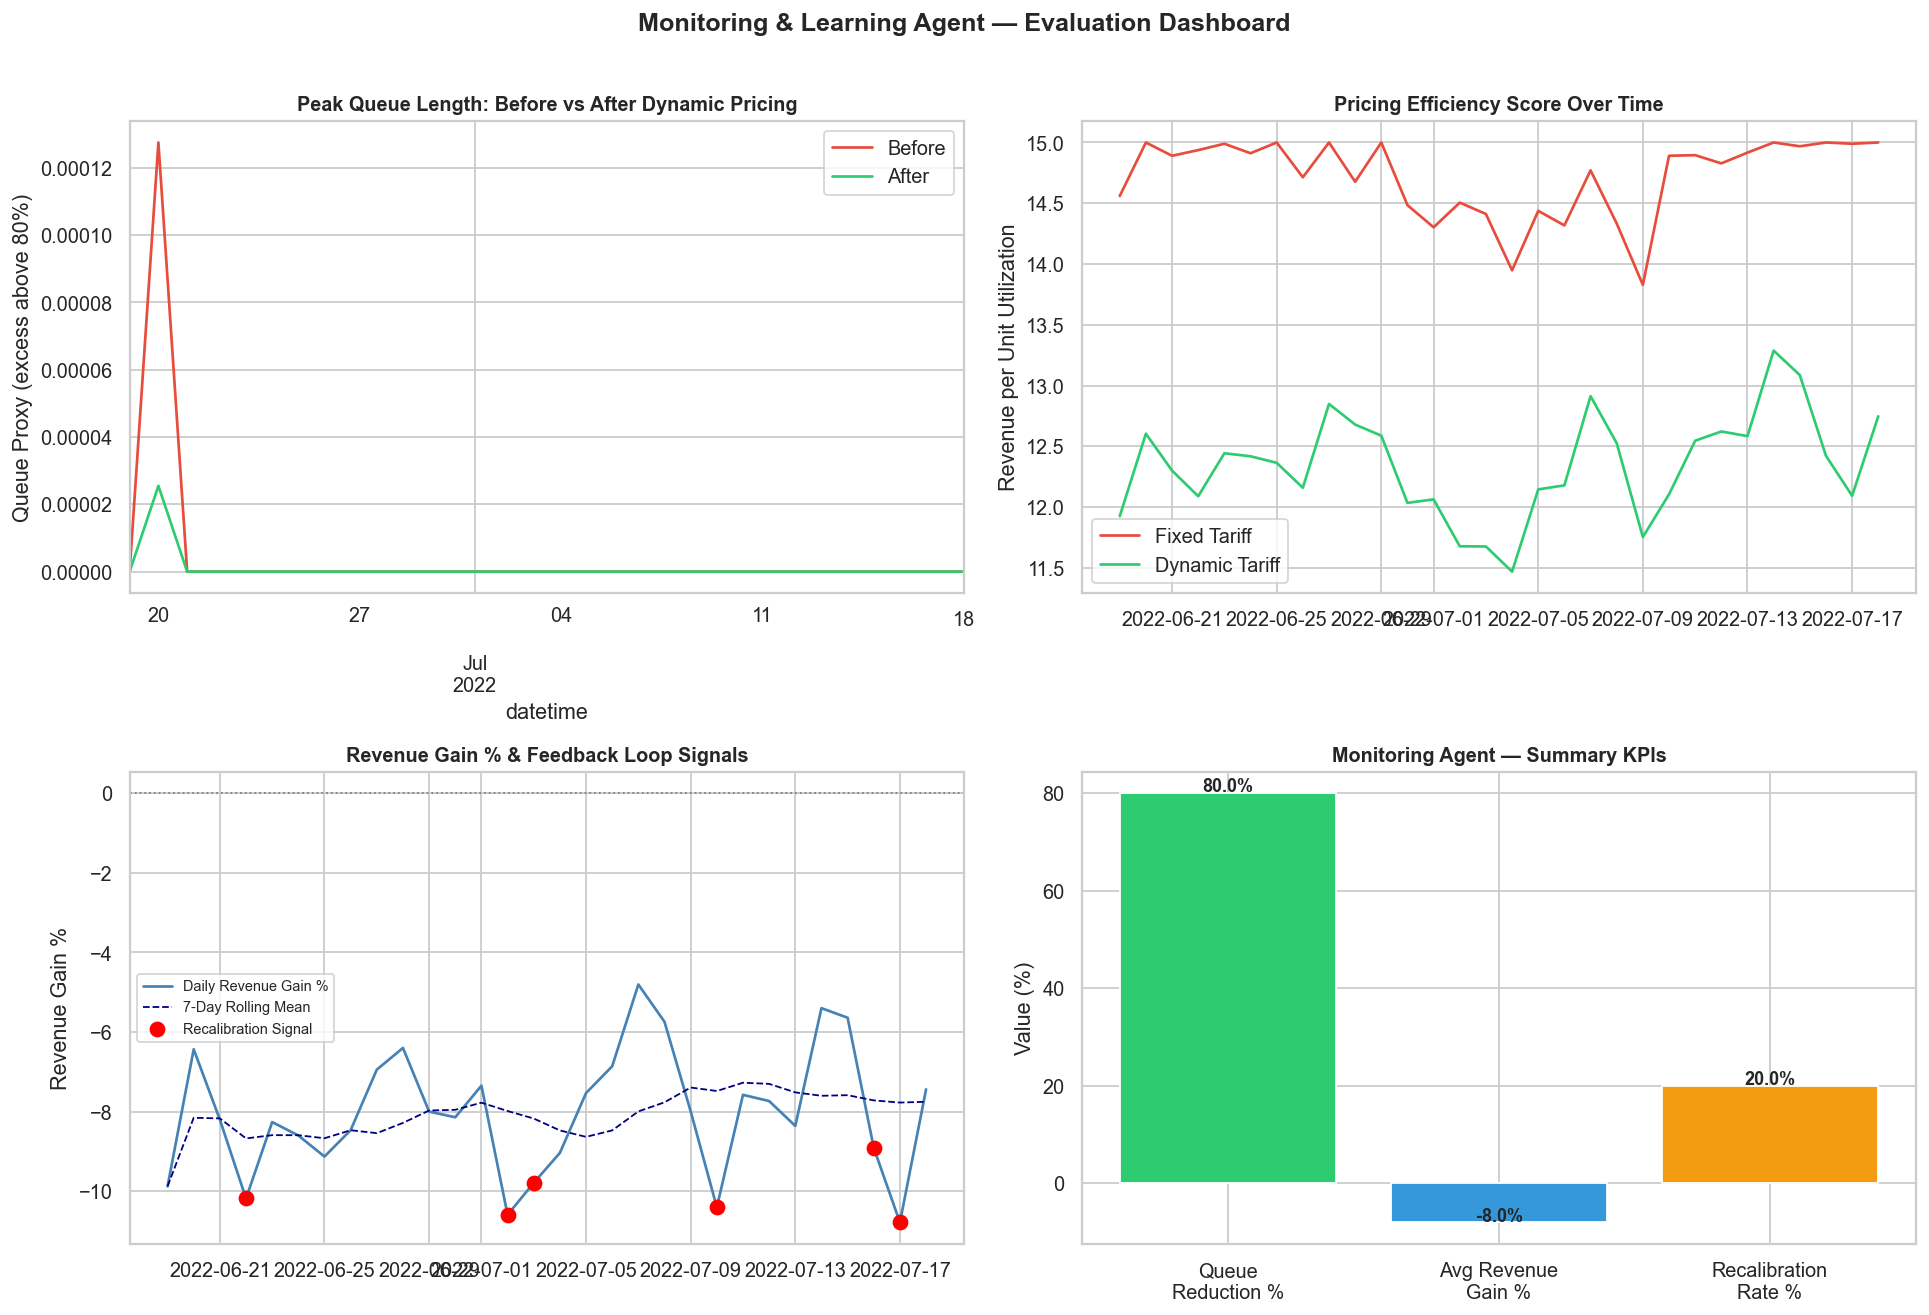

 Saved: monitoring_agent_dashboard.png


In [7]:
tariff_df_peak = tariff_df[peak_mask].copy().set_index('datetime')
daily_queue    = tariff_df_peak.resample('D').agg(
    queue_before=('queue_before','mean'),
    queue_after =('queue_after', 'mean')
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Queue reduction over time
daily_queue.plot(ax=axes[0,0], color=['#e74c3c','#2ecc71'], lw=1.5)
axes[0,0].set_title('Peak Queue Length: Before vs After Dynamic Pricing',
                     fontsize=11, fontweight='bold')
axes[0,0].set_ylabel('Queue Proxy (excess above 80%)')
axes[0,0].legend(['Before','After'])

# 2. Pricing efficiency score over time
axes[0,1].plot(daily_eff['date'], daily_eff['eff_fixed'],
               label='Fixed Tariff',   color='#e74c3c', lw=1.5)
axes[0,1].plot(daily_eff['date'], daily_eff['eff_dynamic'],
               label='Dynamic Tariff', color='#2ecc71', lw=1.5)
axes[0,1].set_title('Pricing Efficiency Score Over Time',
                     fontsize=11, fontweight='bold')
axes[0,1].set_ylabel('Revenue per Unit Utilization')
axes[0,1].legend()

# 3. Revenue gain % + feedback signals
axes[1,0].plot(daily_eff['date'], daily_eff['revenue_gain_pct'],
               color='steelblue', lw=1.5, label='Daily Revenue Gain %')
axes[1,0].plot(daily_eff['date'], daily_eff['rolling_gain_mean'],
               color='navy', lw=1, ls='--', label='7-Day Rolling Mean')
recal_days = daily_eff[daily_eff['recalibration_signal'] == 1]
axes[1,0].scatter(recal_days['date'], recal_days['revenue_gain_pct'],
                  color='red', s=60, zorder=5, label='Recalibration Signal')
axes[1,0].axhline(0, color='gray', ls=':', lw=1)
axes[1,0].set_title('Revenue Gain % & Feedback Loop Signals',
                     fontsize=11, fontweight='bold')
axes[1,0].set_ylabel('Revenue Gain %')
axes[1,0].legend(fontsize=8)

# 4. KPI summary bar
kpi_names = ['Queue\nReduction %', 'Avg Revenue\nGain %', 'Recalibration\nRate %']
kpi_vals  = [queue_reduction, float(daily_eff['revenue_gain_pct'].mean()), recal_rate]
colors    = ['#2ecc71','#3498db','#f39c12']
bars = axes[1,1].bar(kpi_names, kpi_vals, color=colors, edgecolor='white')
axes[1,1].set_title('Monitoring Agent — Summary KPIs', fontsize=11, fontweight='bold')
axes[1,1].set_ylabel('Value (%)')
for bar, val in zip(bars, kpi_vals):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Monitoring & Learning Agent — Evaluation Dashboard',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(PLOTS + "monitoring_agent_dashboard.png", bbox_inches='tight')
plt.show()
print(" Saved: monitoring_agent_dashboard.png")

In [8]:
# Final monitoring summary CSV
surge_row    = response[response['tariff_regime'] == 'Surge']
discount_row = response[response['tariff_regime'] == 'Discount']

monitoring_summary = pd.DataFrame({
    'Metric': [
        'Avg Waiting Time Reduction (Queue Proxy)',
        'Customer Response — Surge Regime (demand change)',
        'Customer Response — Discount Regime (demand change)',
        'Pricing Efficiency — Dynamic Score',
        'Pricing Efficiency — Fixed Score',
        'Recalibration Signals Triggered',
        'Total Monitoring Days',
        'Avg Daily Revenue Gain %'
    ],
    'Value': [
        f"{queue_reduction:.2f}%",
        f"{surge_row['avg_demand_change'].values[0]*100:.2f}%"    if len(surge_row)    > 0 else 'N/A',
        f"{discount_row['avg_demand_change'].values[0]*100:.2f}%" if len(discount_row) > 0 else 'N/A',
        f"{daily_eff['eff_dynamic'].mean():.4f}",
        f"{daily_eff['eff_fixed'].mean():.4f}",
        f"{n_recalibrations}",
        f"{len(daily_eff)}",
        f"{daily_eff['revenue_gain_pct'].mean():.2f}%"
    ],
    'Limitation': [
        'Proxy only — actual wait time data unavailable in dataset',
        'Based on elasticity simulation (ε = −0.3), not observed A/B data',
        'Based on elasticity simulation (ε = −0.3), not observed A/B data',
        'Relative proxy units; not absolute ₹ values',
        'Relative proxy units; not absolute ₹ values',
        'Threshold set at 0.5σ below rolling mean — adjustable',
        'Derived from 5-min interval aggregation',
        'Simulation result; live deployment may differ'
    ]
})

monitoring_summary.to_csv(OUT + "monitoring_summary.csv", index=False)
print(monitoring_summary.to_string(index=False))

                                             Metric   Value                                                       Limitation
           Avg Waiting Time Reduction (Queue Proxy)  79.98%        Proxy only — actual wait time data unavailable in dataset
   Customer Response — Surge Regime (demand change) -15.00% Based on elasticity simulation (ε = −0.3), not observed A/B data
Customer Response — Discount Regime (demand change)   8.69% Based on elasticity simulation (ε = −0.3), not observed A/B data
                 Pricing Efficiency — Dynamic Score 12.3447                      Relative proxy units; not absolute ₹ values
                   Pricing Efficiency — Fixed Score 14.7169                      Relative proxy units; not absolute ₹ values
                    Recalibration Signals Triggered       6            Threshold set at 0.5σ below rolling mean — adjustable
                              Total Monitoring Days      30                          Derived from 5-min interval aggregation
